The purpose of this notebook is to practice/debug translating annotations from stored to the page in which the figures are injected.

In [1]:
#save_json_dir = '/Users/jnaiman/Dropbox/wwt_image_extraction/FullProcess_resources/arxiv_test_jsons/' # small test
save_json_dir = '/Users/jnaiman/Dropbox/wwt_image_extraction/FullProcess_resources/arxiv_new_jsons/' # larger test

# base arxiv dir?
arxiv_dir = '/Users/jnaiman/Dropbox/wwt_image_extraction/arxiv_new/'

# save tmp files
tmp_dir = '/Users/jnaiman/Downloads/tmp/tiff_files/'


In [2]:
from glob import glob
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import json


# debug
from importlib import reload
import arxiv_mining_synthetic_data.utils.parse_output_utils
import utils.misc_utils
import synthetic_training_figures.utils.figure_gen_utils.misc
reload(utils.misc_utils)
reload(arxiv_mining_synthetic_data.utils.parse_output_utils)
reload(synthetic_training_figures.utils.figure_gen_utils.misc)

from arxiv_mining_synthetic_data.utils.parse_output_utils import full_clean_df
from utils.misc_utils import df_with_aspects
#from synthetic_training_figures.utils.figure_gen_utils.misc import add_annotations
from arxiv_mining_synthetic_data.utils.pdf_utils import save_pages


In [3]:
# FUNCTIONS
from copy import deepcopy

def get_nsubfigs(figure_box): # e.g. {'figure 1': ..}
    nsubfigs = 0
    for b,v in figure_box.items():
        if 'subfig ' in b: # there is a subfig
            nsubfigs += 1
    return nsubfigs


def create_subfig_params(nsubfigs, figure_box):
    if nsubfigs == 0: # no subfigs
        return '','',True

    err = False

    # get all of the figure_params for each of the subfigures
    subfig_params = {}
    for i in range(0,nsubfigs):
        bbox = figure_box['subfig '+str(i)]
        w = np.abs(bbox['xmax']-bbox['xmin'])
        h = np.abs(bbox['ymax']-bbox['ymin'])
        figure_params, font_params = get_various_plot_params(nrows=1, ncols=1, 
            aspect_ratio=w/h)
        if i == 0:
            subfig_params[i] = deepcopy(figure_params)
        else:
            # replace with first subfig params for things like plot style, colormap, etc
            figure_params['color map'] = subfig_params[0]['color map']
            figure_params['plot style'] = subfig_params[0]['plot style']
            figure_params['flipped font/face colors'] = subfig_params[0]['flipped font/face colors']
            figure_params['tight_layout'] = subfig_params[0]['tight_layout']
            ## JPN -- here you might want to ensure the inbetween-padding is small
            for x in ['layout pad','layout h_pad','layout w_pad','layout hspace','layout wspace']:
                figure_params[x] = subfig_params[0][x]
            subfig_params[i] = deepcopy(figure_params)

    return subfig_params, font_params, err


def get_page_info(d):
    figure_boxes = d['boxes'].values[0] #['figure 1']
    adir = d['article'].values[0]
    adir1 = adir[:4]
    adir2 = adir[4:].removeprefix('_')
    adirfull = arxiv_dir + adir1 + '/' + adir2 + '/'
    fake_figs_dir = adirfull + 'synthetic_figures_RTM' + '/'
    return figure_boxes, fake_figs_dir

In [4]:
files_json = glob(save_json_dir + '*.json')
# make sure sorted
files_json.sort()
files_json[:3]

['/Users/jnaiman/Dropbox/wwt_image_extraction/FullProcess_resources/arxiv_new_jsons/2301_2301.00001d.json',
 '/Users/jnaiman/Dropbox/wwt_image_extraction/FullProcess_resources/arxiv_new_jsons/2301_2301.00002d.json',
 '/Users/jnaiman/Dropbox/wwt_image_extraction/FullProcess_resources/arxiv_new_jsons/2301_2301.00003d.json']

In [5]:
df_full_clean = full_clean_df(files_json, verbose=True, big_shift=1)

# also get df with aspects
df_af = df_with_aspects(df_full_clean)

---- Collecting all JSONs ----
Total number of figs: 17110
Total processed articles: 6235

---- Parsing Errors at article-level ----
there are: 2364 articles with no error *at the article level*

---- Parsing Errors at page-level ----
There are 13638 from the no-article-level-error dataset
There are 13622 pages without figures marked larger than the article page

just for large shift (new-old)
  - there are 12517 pages with this condition out of 13638 pages without error, or 91.78%


In [6]:
# grab random one to check
#iplot = np.random.choice(np.arange(len(df_full_clean)), replace=False, size=1)
iplot = [7430] # known subfig
print('iplot = ', iplot)
# which subfig?
isubfig = 0

d = df_full_clean.iloc[iplot]
figure_boxes, fake_figs_dir = get_page_info(d)

print(d['boxes'].values)
print('subfig #:', isubfig)
print(fake_figs_dir)

iplot =  [7430]
[{'figure 1': {'xmin': 697.0304230230387, 'ymin': 847.9746920726961, 'xmax': 1776.680587445517, 'ymax': 461.349949894925, 'subfig 0': {'xmin': 697.0304230230387, 'ymin': 847.9746920726961, 'xmax': 1219.5537486379203, 'ymax': 461.349949894925}, 'subfig 1': {'xmin': 1254.1572618306352, 'ymin': 847.9746920726961, 'xmax': 1776.680587445517, 'ymax': 461.349949894925}, 'mean': 0.0, 'median': 0.0, 'sum': 0, 'mean (bulk pdf)': 1.9955354579385587, 'median (bulk pdf)': 0.0, 'sum (bulk pdf)': 2502162, 'shift-y': 0.0, 'shift-x': 0.0, 'shift phase': -3.144306203129466e-36, 'shift (bulk pdf)-y': 0.0, 'shift (bulk pdf)-x': 0.0, 'shift phase (bulk pdf)': 1.0219834066507453e-18}}]
subfig #: 0
/Users/jnaiman/Dropbox/wwt_image_extraction/arxiv_new/2302/2302.05526d/synthetic_figures_RTM/


In [7]:
# reconstruct on old/new page
# usual params
fac_dpi = 4
fac_down_dpi = 1

fname = arxiv_dir + d['article'].values[0][:4] + \
    '/' + d['article'].values[0][5:] + \
        '/' + d['tex name'].values[0] + '.tex'
fname

#beginner = fname.split('/')[-2].replace('.', '_') + '_'
beginner = d['article'].values[0]

# make page
page_errors = save_pages(fname, 
           [d['page num'].values[0]],tmp_dir,check_exist=False, 
           fac_dpi=fac_dpi, 
           fac_down_dpi = 1.0/fac_down_dpi,
          save_fmt = 'tiff', 
          beginner=beginner, return_error=True)
if page_errors[0]:
    print('Issue creating OLD page')
    import sys; sys.exit()

******** ON SUBFIG 1 of 2 ************
******** ON SUBFIG 2 of 2 ************
2302_2302.05526d_page0012_figure000_subfig0000
{'xmin': 175.20024768769025, 'ymin': 185.25456441910268, 'xmax': 2238.4058711471816, 'ymax': 1850.1918902507036}
2302_2302.05526d_page0012_figure000_subfig0001
{'xmin': 147.28243057709338, 'ymin': 166.41274643957317, 'xmax': 2557.066562196603, 'ymax': 1782.98308689376}


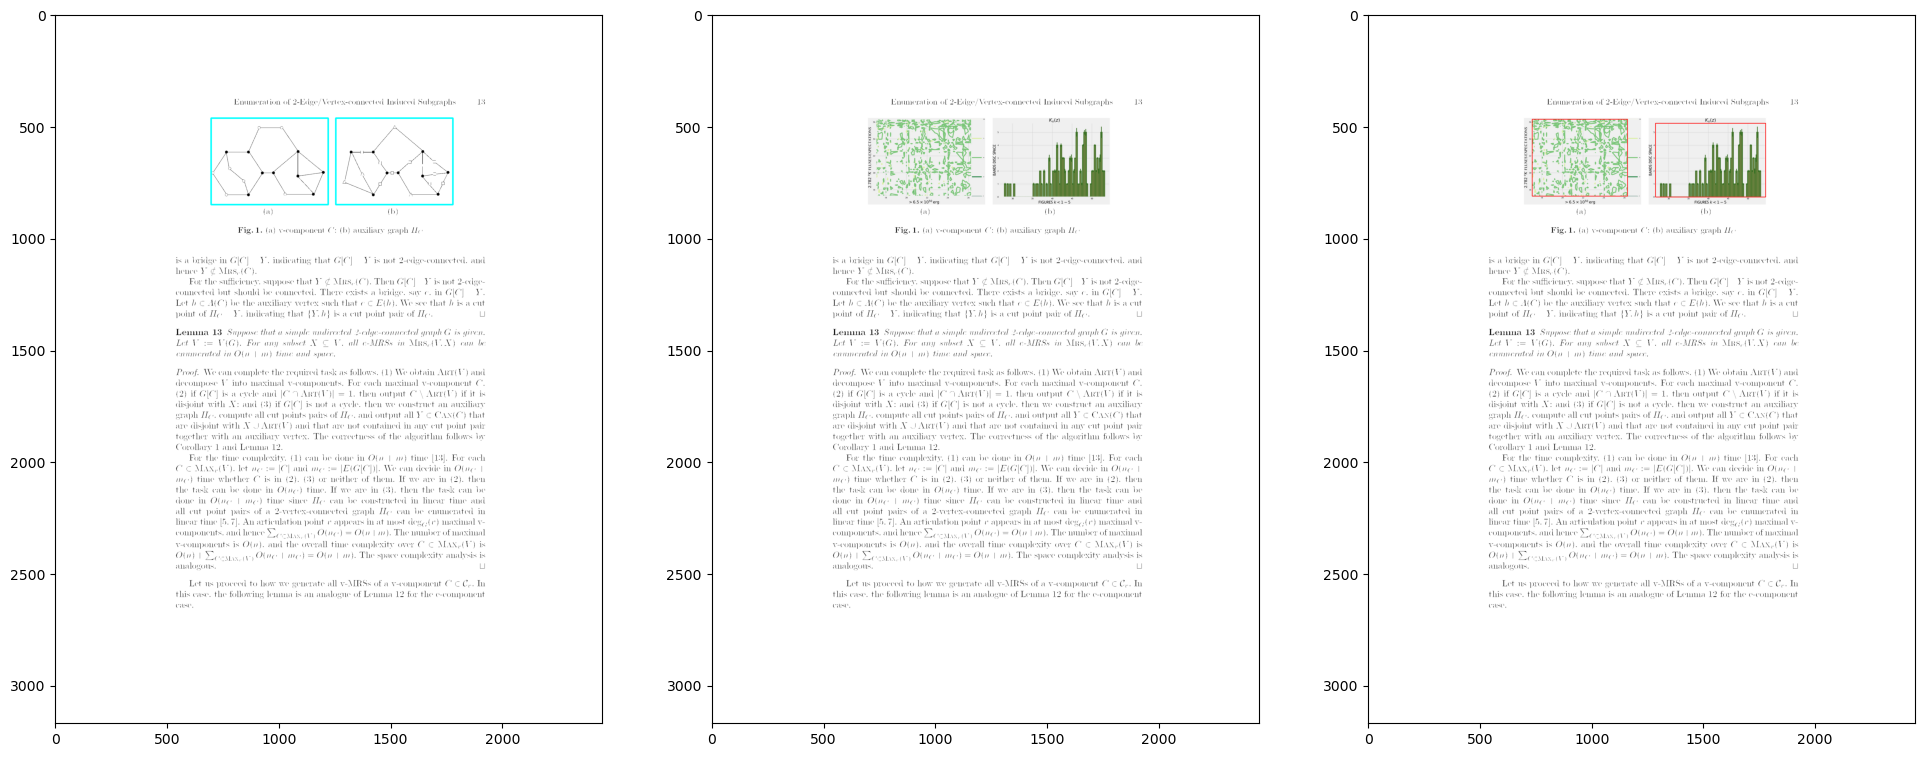

In [8]:
# debug
reload(synthetic_training_figures.utils.figure_gen_utils.misc)
#from synthetic_training_figures.utils.figure_gen_utils.misc import add_annotations
import cv2 as cv

# option -- connect with facecolor?
connect_facecolor_prob = 0.5 # probablity of connecting

# open each
nfig = 3
plt.style.use('default')
fig, ax = plt.subplots(1,nfig, figsize=(8*nfig, 11.5))

img_orig = beginner+d['tex name'].values[0] + '_p'+str(d['page num'].values[0])
with Image.open(tmp_dir + img_orig + '.tiff').convert('RGB') as img_in:
    img_orig = np.array(img_in)  
img_save = img_orig.copy() 
for fboxname, figure_box in figure_boxes.items():
    nsubfigs = get_nsubfigs(figure_box)
    #boxes = d['boxes'].values[0]['figure '+str(main_fig_num+1)]
    boxes = d['boxes'].values[0][fboxname]
    for subfigNum in range(nsubfigs):
        # draw latex boxes
        bs = boxes['subfig ' + str(subfigNum)]
        xmin,ymin = int(round(bs['xmin'])),int(round(bs['ymin']))
        xmax,ymax = int(round(bs['xmax'])),int(round(bs['ymax']))
        cv.rectangle(img_orig, (xmin,ymin), (xmax,ymax), (0,255,255), 5)
ax[0].imshow(img_orig)

img_new = img_save.copy()
img_inject = img_save.copy()

for fboxname, figure_box in figure_boxes.items():
    main_fig_num = int(fboxname.split('figure')[-1])-1
    # load images
    main_fig_num = 0 # number on page

    # just get a initial subfig
    figure_name = str(d['article'].values[0]) + '_page' + str(d['page num'].values[0]).zfill(4) + \
        '_figure' + str(main_fig_num).zfill(3) + '_subfig' + str(0).zfill(4) # just take "base" subfig
    # read in a figure to get facecolor
    with open(fake_figs_dir+'jsons/' + figure_name + '.json','r') as f:
        data = json.load(f)
        data = json.loads(data)

    # set background to facecolor
    box = d['boxes'].values[0]['figure '+str(main_fig_num+1)]
    nsubfigs = get_nsubfigs(figure_box)
    if np.random.random() <= connect_facecolor_prob:
        #print('yes, connect facecolor')
        xmin,ymin,xmax,ymax = int(round(box['xmin'])),int(round(box['ymin'])),int(round(box['xmax'])),int(round(box['ymax']))
        facecolor = np.array(data['figure']['facecolor'])
        if np.array(data['figure']['facecolor']).dtype == 'float' and img_new.dtype == 'uint8':
            facecolor = np.round(facecolor*255).astype('uint8')[:3]
        img_new[ymax:ymin,xmin:xmax,:] = facecolor
        img_inject[ymax:ymin,xmin:xmax,:] = facecolor


    boxes = d['boxes'].values[0]['figure '+str(main_fig_num+1)]
    #for subfigNum, subparams in subfig_params.items():
    for subfigNum in range(nsubfigs):
        print('******** ON SUBFIG', subfigNum+1, 'of', nsubfigs, '************')
        box = boxes['subfig ' + str(subfigNum)]
        figure_name = str(d['article'].values[0]) + '_page' + str(d['page num'].values[0]).zfill(4) + \
            '_figure' + str(main_fig_num).zfill(3) + '_subfig' + str(subfigNum).zfill(4)
        with Image.open(fake_figs_dir + 'imgs/'+figure_name + '.jpeg') as img:
            # resize
            h,w = box['ymin']-box['ymax'], box['xmax']-box['xmin']
            new_size = (int(round(w)),int(round(h)))
            resized_img = img.resize(new_size, Image.Resampling.LANCZOS)
            img_in = np.array(resized_img)
            # place
            xmin,ymin,xmax,ymax = int(round(box['xmin'])),int(round(box['ymin'])),int(round(box['xmax'])),int(round(box['ymax']))
            img_new[ymax:ymin,xmin:xmax] = img_in
            img_inject[ymax:ymin,xmin:xmax,:] = img_in


ax[1].imshow(img_new)


# update with boxes
img_boxes = img_inject.copy()
for fboxname, figure_box in figure_boxes.items():
    main_fig_num = int(fboxname.split('figure')[-1])-1
    # load images
    main_fig_num = 0 # number on page

    # bounding box for new fig
    box = d['boxes'].values[0]['figure '+str(main_fig_num+1)]

    nsubfigs = get_nsubfigs(figure_box)
    # for subfigNum, subparams in subfig_params.items():
    for subfigNum in range(nsubfigs):
        figure_name = str(d['article'].values[0]) + '_page' + str(d['page num'].values[0]).zfill(4) + \
            '_figure' + str(main_fig_num).zfill(3) + '_subfig' + str(subfigNum).zfill(4) # just take "base" subfig
        # read in a figure to get facecolor
        print(figure_name)
        with open(fake_figs_dir+'jsons/' + figure_name + '.json','r') as f:
            data = json.load(f)
            data = json.loads(data)

        bs = box['subfig ' + str(subfigNum)]
        #print(bs)
        # xmin,ymin = int(round(bs['xmin'])),int(round(img_new.shape[0]-bs['ymin']))
        # xmax,ymax = int(round(bs['xmax'])),int(round(img_new.shape[0]-bs['ymax']))
        # xmin,ymin = int(round(bs['xmin'])),int(round(bs['ymin']))
        # xmax,ymax = int(round(bs['xmax'])),int(round(bs['ymax']))
        # for know subfig -- only 1 plot!!
        sq = data['plot0']['square'] # this is from the plot data
        print(sq)
        #w_old = sq['xmax']-sq['xmin']
        w_old = data['figure']['pixel width']
        w_new = bs['xmax']-bs['xmin']
        xmin_new = bs['xmin'] + sq['xmin']/w_old*w_new
        xmax_new = bs['xmin'] + sq['xmax']/w_old*w_new
        h_old = data['figure']['pixel height']
        h_new = bs['ymin']-bs['ymax']
        # MIN/MAX SWAPPED FOR SQUARE
        bs_ymax = bs['ymax']
        #bs_ymax = img_boxes.shape[0] - bs['ymax']
        #bs_ymax = bs['ymax'] - img_boxes.shape[0]
        #bs_ymin = img_boxes.shape[0] - bs['ymin']
        ymin_new = bs_ymax + (data['figure']['pixel height']-sq['ymin'])/h_old*h_new
        ymax_new = bs_ymax + (data['figure']['pixel height']-sq['ymax'])/h_old*h_new
        #ymin_new = bs['ymin']
        #cv.rectangle(img_boxes, (xmin_new, ))
        #print('wold,wnew,hold,hnew',w_old,w_new,h_old,h_new)
        # print('xmin_new = ', xmin_new)
        # print('xmax_new=', xmax_new)
        xmin_new,ymin_new = int(round(xmin_new)),int(round(ymin_new))
        xmax_new,ymax_new = int(round(xmax_new)),int(round(ymax_new))
        cv.rectangle(img_boxes, (xmin_new,ymin_new), (xmax_new,ymax_new), (255,0,0), 2)
        

ax[2].imshow(img_boxes)

# Rescale annotations

2302_2302.05526d_page0012_figure000_subfig0000
2302_2302.05526d_page0012_figure000_subfig0001
plot0 : no colorbar for this type


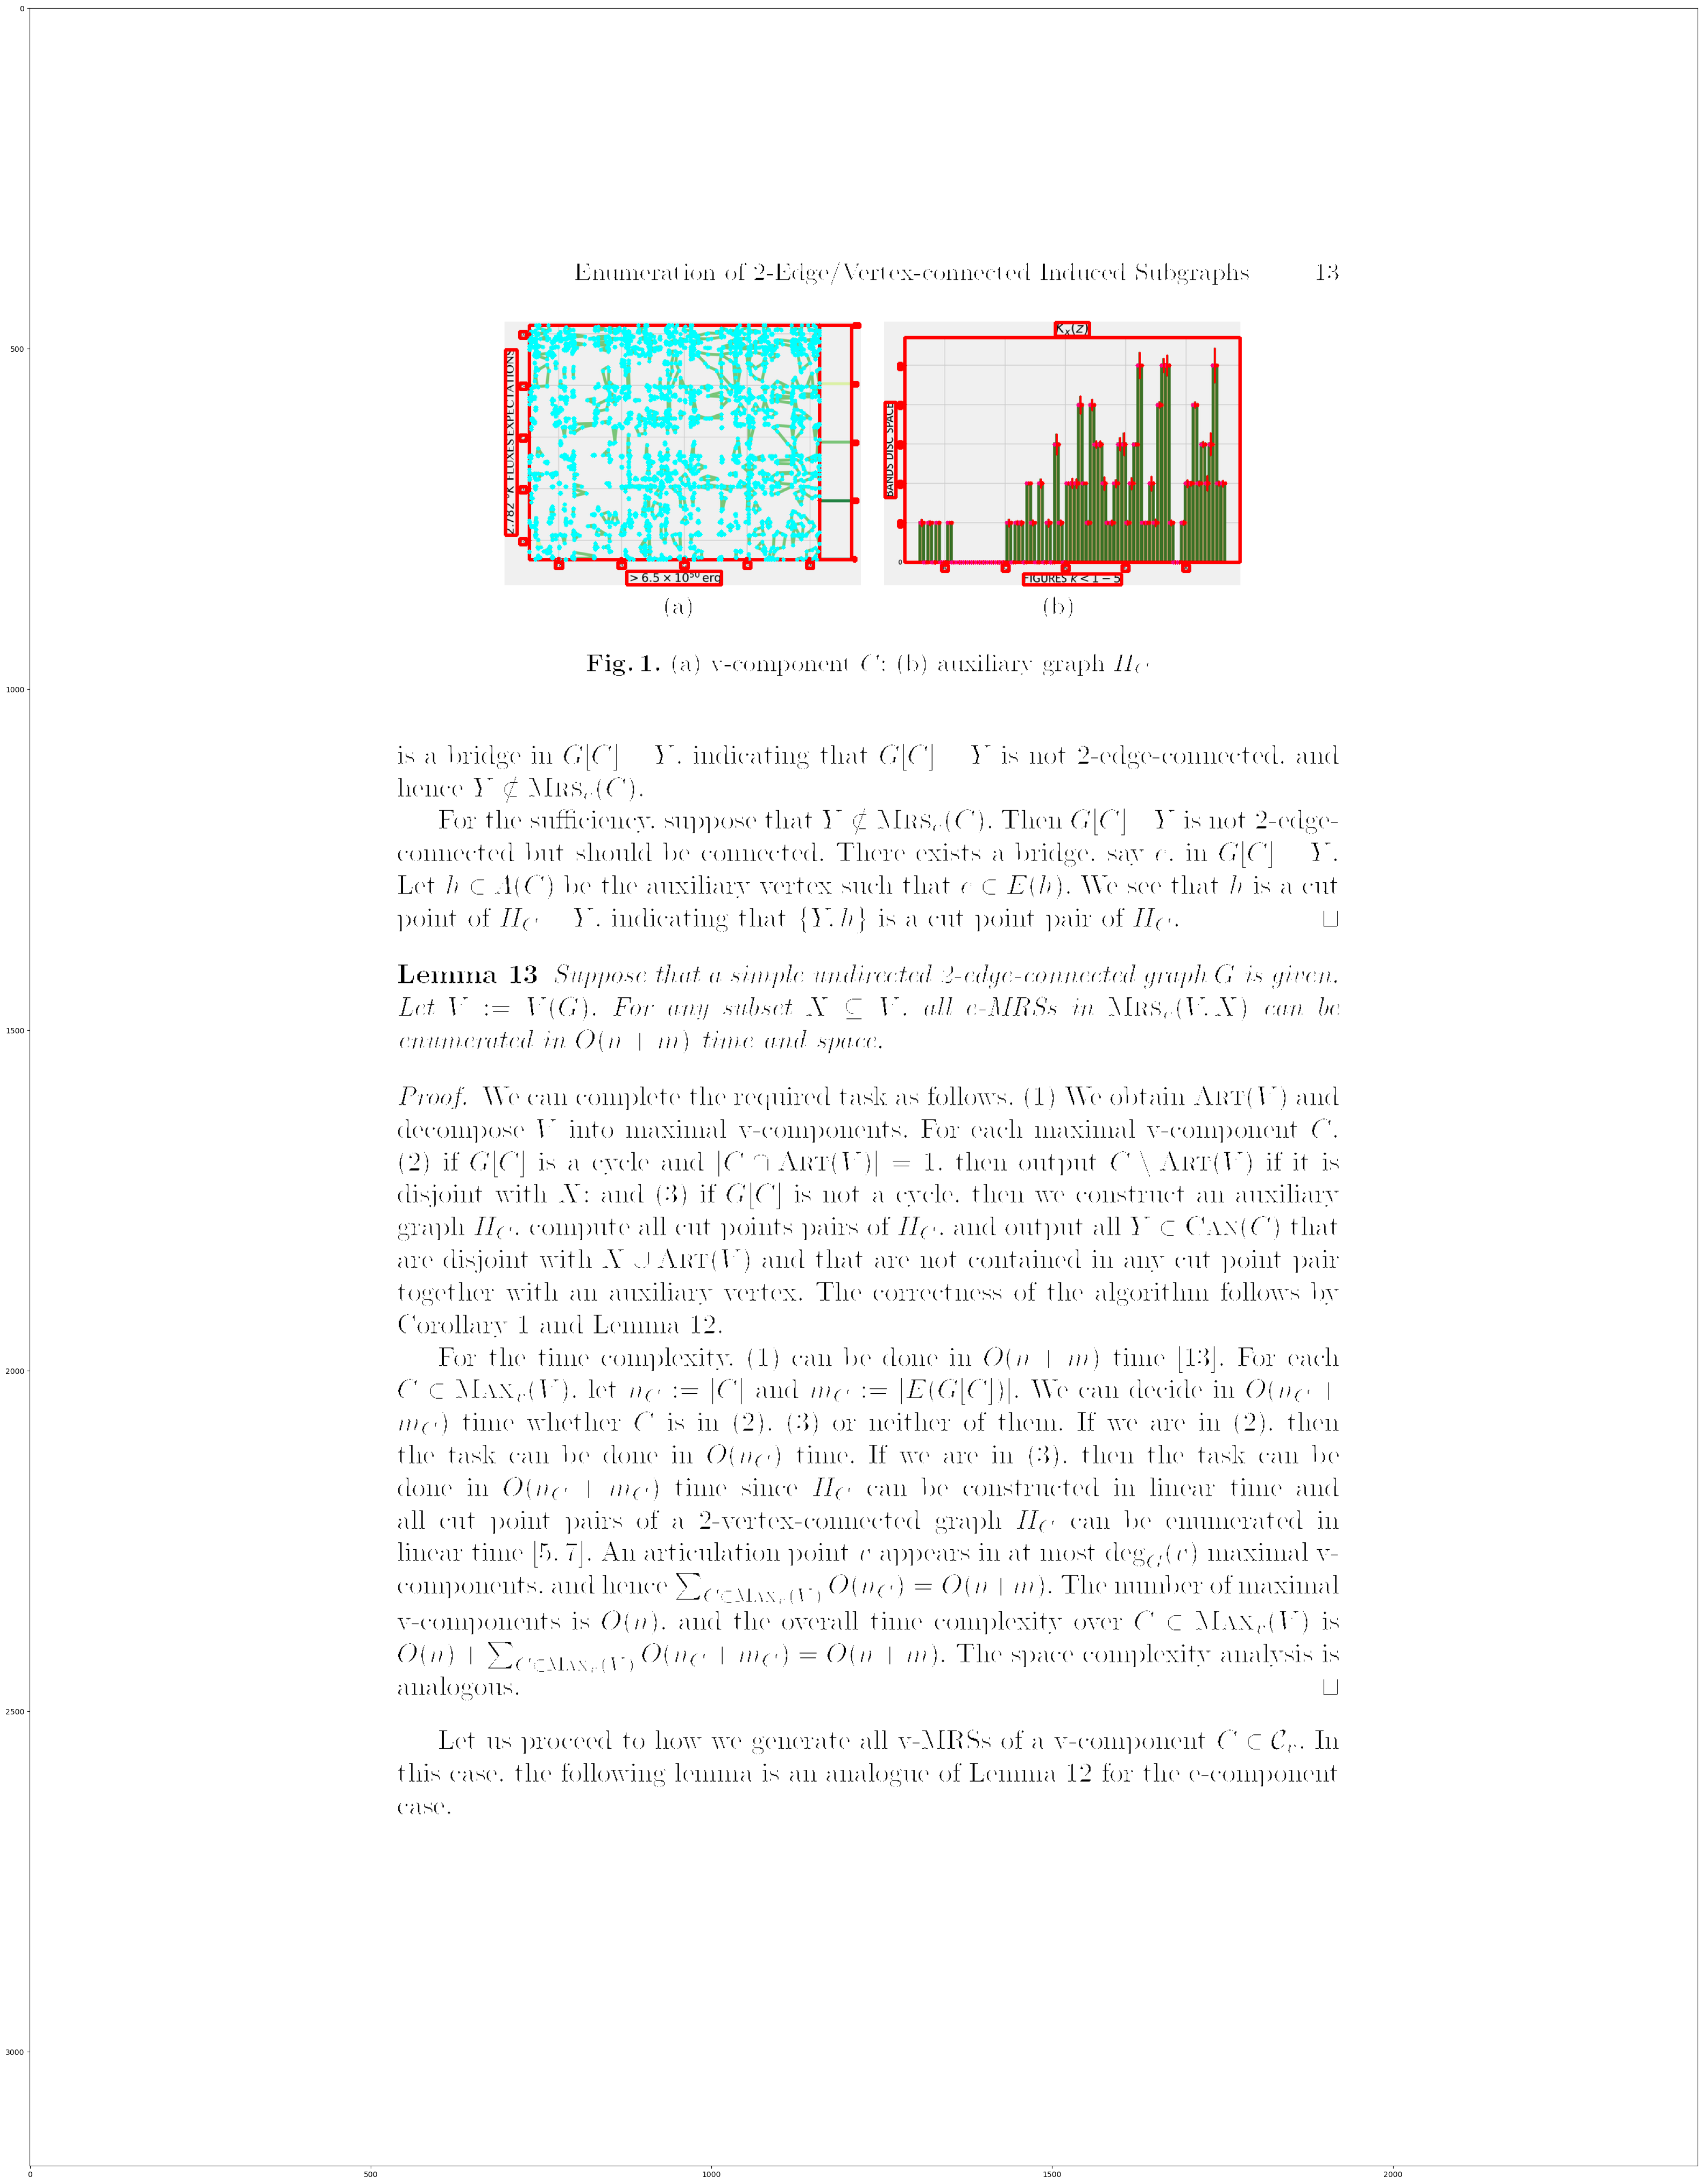

In [9]:
import utils.translation_utils
reload(utils.translation_utils)
from utils.translation_utils import translate_data
import utils.annotation_utils_translate
reload(utils.annotation_utils_translate)
from utils.annotation_utils_translate import add_annotations

# close up
fac=5
fig, ax = plt.subplots(figsize=(8*fac,11.5*fac))
# update with boxes
img_boxes = img_inject.copy()
for fboxname, figure_box in figure_boxes.items():
    main_fig_num = int(fboxname.split('figure')[-1])-1
    # load images
    main_fig_num = 0 # number on page

    # bounding box for new fig
    box = d['boxes'].values[0]['figure '+str(main_fig_num+1)]

    nsubfigs = get_nsubfigs(figure_box)
    # for subfigNum, subparams in subfig_params.items():
    for subfigNum in range(nsubfigs):
        #if subfigNum > 0: # debug
        #    continue
        figure_name = str(d['article'].values[0]) + '_page' + str(d['page num'].values[0]).zfill(4) + \
            '_figure' + str(main_fig_num).zfill(3) + '_subfig' + str(subfigNum).zfill(4) # just take "base" subfig
        # read in a figure to get facecolor
        print(figure_name)
        with open(fake_figs_dir+'jsons/' + figure_name + '.json','r') as f:
            data = json.load(f)
            data = json.loads(data)

        bs = box['subfig ' + str(subfigNum)]
        datatr = translate_data(data, bs, plot_num=0, roundit=False) # plot_num = 0 for all because putting each figure generated separately in
        img_boxes = add_annotations(deepcopy(img_boxes), deepcopy(datatr), verbose=False, csize=3, flip_ycoord=False)


        

ax.imshow(img_boxes)

In [10]:
img_boxes

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [11]:
datatr['plot0']['square']

{'xmin': 1284.2074396634293,
 'ymin': 814.0225626862609,
 'xmax': 1775.8780442974771,
 'ymax': 484.2040449604922}

In [12]:
datatr['plot0']['xticks']

[{'xmin': 1338.1074470134645,
  'ymin': 826.7584532148302,
  'xmax': 1348.2579879932928,
  'ymax': 817.7814143463227,
  'data': '30',
  'tx': 1343.1827175033786,
  'ty': 814.0225626862609},
 {'xmin': 1426.5189147456438,
  'ymin': 826.7584532148302,
  'xmax': 1436.669455725472,
  'ymax': 817.7814143463227,
  'data': '35',
  'tx': 1431.594185235558,
  'ty': 814.0225626862609},
 {'xmin': 1514.930382477823,
  'ymin': 826.7584532148302,
  'xmax': 1525.0809234576514,
  'ymax': 817.7814143463227,
  'data': '40',
  'tx': 1520.0056529677372,
  'ty': 814.0225626862609},
 {'xmin': 1603.3418502100023,
  'ymin': 826.7584532148302,
  'xmax': 1613.4923911898309,
  'ymax': 817.7814143463227,
  'data': '45',
  'tx': 1608.4171206999167,
  'ty': 814.0225626862609},
 {'xmin': 1691.7533179421816,
  'ymin': 826.7584532148302,
  'xmax': 1701.9038589220102,
  'ymax': 817.7814143463227,
  'data': '50',
  'tx': 1696.828588432096,
  'ty': 814.0225626862609}]